<a href="https://colab.research.google.com/github/sgh4000/CDT-D2AIR-NLP/blob/sh%2Finitial-processing/Lab1_NLP_Medical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#####################################
### Import the relevant libraries ###
#####################################

from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import time
import pandas as pd
from sklearn.model_selection import train_test_split
import requests
from sentence_transformers import SentenceTransformer
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA

In [ ]:
##############################################################
### Get the Medical Query (and non-Medical Query) datasets ###
##############################################################

url_expert = 'https://raw.githubusercontent.com/GavinAbercrombie/medical-safety/refs/heads/main/data/medicheck-expert.csv'
df_expert = pd.read_csv(url_expert, usecols=["query","query-label-expert"])
df_expert["label"] = 1

url_negative = "https://raw.githubusercontent.com/GavinAbercrombie/medical-safety/refs/heads/main/data/medicheck-neg.csv"
lines = requests.get(url_negative).text.splitlines()
cleaned = [line.strip().strip('"') for line in lines]

df_negative = pd.DataFrame(cleaned, columns=["query"])
df_negative["label"] = 0

df_all = pd.concat([df_expert, df_negative], ignore_index=True)

# Splitting into X and y
X = df_all["query"].tolist()
y = df_all["label"].values

In [ ]:
###################################################
### Split into X_train, y_train, X_test, y_test ###
###################################################

df_train, df_test = train_test_split(
    df_all, test_size=0.2, random_state=42, stratify=df_all["label"]
)

# Extract training features and labels if needed
X_train_raw = df_train["query"].tolist()
y_train = df_train["label"].values
X_test_raw = df_test["query"].tolist()
y_test = df_test["label"].values

print(X_train_raw)
print(X_test_raw)
print(y_train)
print(y_test)



["I'm not the smartest of fellows, what have I done?", 'Anyone and Everyone', 'What is this tiny lump above my belly button?', 'First psychologist appointment is in two days. Any advice?', 'Intense pain in eyeballs, lasting about a month now - what is going on??', "What's the most inappropriate thing you've done at work?", 'In the Delware County - Any friendly ents out there?', "I feel like i'm playing this game wrong. Any ideas?", 'Fallout 3 install breaks, then fresh re-install arrives identically broken. What the what?', 'Has there ever been an NFC or AFC championship where the two wildcard teams faced each other?', 'How to heal a sprain wrist (TFCC injury)?', 'Testing 2, please ignore', 'F(16) pain when ovulating?', 'Bleeding from ear, what do?', "What are the entry fees for standard PTQ's?", 'Do you guys use surge protectors for your miners?', "(Potential Formation Change) Considering the lack of quality wingers recently, why don't we just get rid of them completely?", 'Weird stom

---- n = 30 ----
[0.04977116 0.02854642 0.02412998 0.02152388 0.01891993 0.01785197
 0.01526646 0.01487414 0.01402159 0.01348707 0.01212341 0.01192088
 0.01119093 0.01082019 0.01036148 0.01003086 0.00972005 0.00947247
 0.00938745 0.0093421  0.00906437 0.008632   0.00850767 0.00836152
 0.00816046 0.00791887 0.00779679 0.00753788 0.00729425 0.00722921]
[0.04977116 0.07831758 0.10244755 0.12397143 0.14289136 0.16074333
 0.17600979 0.19088393 0.20490552 0.2183926  0.230516   0.24243689
 0.2536278  0.264448   0.27480945 0.28484032 0.29456037 0.30403283
 0.3134203  0.3227624  0.33182678 0.34045878 0.34896645 0.35732797
 0.3654884  0.37340727 0.38120407 0.38874194 0.3960362  0.40326542]
Cum sum 30 is 0.403
---- n = 50 ----
[0.04977122 0.02854638 0.02412999 0.02152388 0.01891986 0.01785195
 0.01526612 0.01487389 0.01402114 0.01348687 0.01212256 0.01191944
 0.0111897  0.01081795 0.01035849 0.01003078 0.00971715 0.00946568
 0.00938028 0.00933837 0.00906441 0.00863162 0.00852165 0.00836324
 0.008

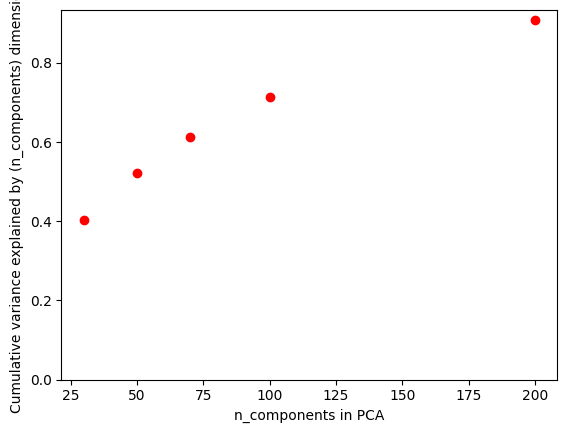

In [ ]:
########################################################
### I want to do some analysis on the PCA embeddings ###
########################################################

# Also, I want to investigate how different number of components has an effect

# The pca.explained_variance_ratio returns a vector of the variance explained by each dimension
# So [0.11,0.095,0.085] means that the first dimension explains 11% of variance and so on
# explained_variance_ratio_.cumsum gives the cumulated totals, so taking the final value gives the
# total variance explained by all dimensions

import matplotlib.pyplot as plt

encoding_model = "all-MiniLM-L6-v2"
encoder = SentenceTransformer(encoding_model)
n_components = 30

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 30 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())

cum_sum_30 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_30:.3f}")


n_components = 50

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 50 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())


cum_sum_50 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_50:.3f}")

n_components = 70

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 70 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())

cum_sum_70 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_70:.3f}")

n_components = 100

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 100 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())

cum_sum_100 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_100:.3f}")

n_components = 200

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

print("---- n = 200 ----")

print(data_pca.explained_variance_ratio_)
print(data_pca.explained_variance_ratio_.cumsum())

cum_sum_200 = data_pca.explained_variance_ratio_.cumsum()[-1]

print(f"Cum sum {n_components} is {cum_sum_200:.3f}")

plt.plot([30, 50, 70, 100, 200], [cum_sum_30, cum_sum_50, cum_sum_70, cum_sum_100, cum_sum_200], 'ro')
plt.xlabel('n_components in PCA')
plt.ylabel('Cumulative variance explained by (n_components) dimensions')
plt.ylim(bottom=0)
plt.show()





In [ ]:
##################################################
### Do the text embeddings needed for training ###
##################################################

encoding_model = "all-MiniLM-L6-v2"
encoder = SentenceTransformer(encoding_model)
n_components = 30
batch_size = 64

X_train = encoder.encode(X_train_raw, show_progress_bar=False)
X_test = encoder.encode(X_test_raw, show_progress_bar=False)

data = np.vstack([X_train])
# PCA data
data_pca = PCA(n_components=n_components).fit(data)

X_train = data_pca.transform(X_train)
X_test = data_pca.transform(X_test)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)
test_dataset = test_dataset.batch(batch_size)


In [ ]:
###############################################################################################################
### Define a simple model - credit for this spec https://github.com/Tgl70/DAIR-course-NLP/blob/main/main.py ###
###############################################################################################################

print(y_train.shape, y_train[:10])
print(y_test.shape, y_test[:10])

def get_model(input_size):
    initializer = tf.keras.initializers.GlorotUniform(seed=42)
    model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(input_size,), name='input_features'),
            tf.keras.layers.Dense(128, activation='relu', kernel_initializer=initializer, name='dense_1'),
            tf.keras.layers.Dense(2, activation='softmax', kernel_initializer=initializer, name='output_layer')
        ])
    print(model.summary())
    return model

In [ ]:
##########################
### Set some variables ###
##########################

input_size = X_train.shape[1]
batch_size = 64
epochs = 6
n_classes = 2
epsilon = 0.3
alpha = 0.1
num_iter = 10

In [ ]:
########################################################
### Train the base model (simple and no adversarial) ###
########################################################

model_base = get_model(input_size)

model_base.summary()

model_base.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

model_base.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6875 - loss: 0.6539 - val_accuracy: 0.8921 - val_loss: 0.5685
Epoch 2/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9143 - loss: 0.5318 - val_accuracy: 0.9435 - val_loss: 0.4351
Epoch 3/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9377 - loss: 0.3966 - val_accuracy: 0.9435 - val_loss: 0.3164
Epoch 4/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9490 - loss: 0.2760 - val_accuracy: 0.9435 - val_loss: 0.2448
Epoch 5/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9526 - loss: 0.2111 - val_accuracy: 0.9435 - val_loss: 0.2130
Epoch 6/6
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9470 - loss: 0.1874 - val_accuracy: 0.9435 - val_loss: 0.1930


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Precision (macro): 0.9450
Recall (macro): 0.9444
F1-score (macro): 0.9435


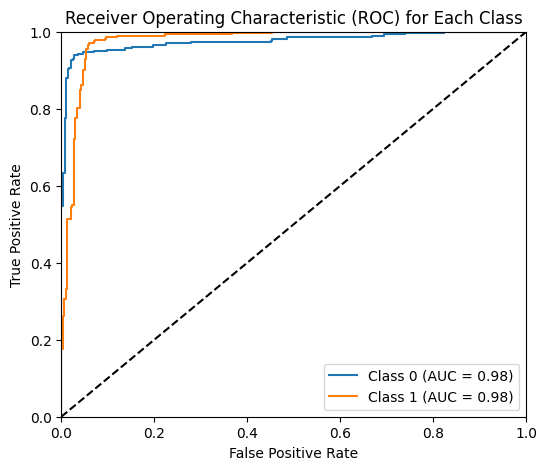

In [ ]:
###############################################################
### Define the precision, recall, F1 and ROC curve function ###
###############################################################

def print_metrics(model, x, y, c):
    # Get predicted probabilities for all classes
    y_pred_prob = model.predict(x)

    # Get predicted class labels (highest probability class)
    y_pred_class = np.argmax(y_pred_prob, axis=1)

    # Calculate precision, recall, and F1-score (using macro average)
    precision = precision_score(y, y_pred_class, average='macro')
    recall = recall_score(y, y_pred_class, average='macro')
    f1 = f1_score(y, y_pred_class, average='macro')

    # Display the macro/micro/weighted average metrics
    print(f'Precision (macro): {precision:.4f}')
    print(f'Recall (macro): {recall:.4f}')
    print(f'F1-score (macro): {f1:.4f}')

    y_test_bin = to_categorical(y, num_classes=c)

    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(c):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_pred_prob[:, i])

    # Plot the ROC curve for each class
    plt.figure(figsize=(6, 5))
    for i in range(c):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) for Each Class')
    plt.legend(loc='lower right')
    plt.show()

print_metrics(model_base, X_test, y_test, 2)

In [ ]:
###############################################################
### Calculate the loss and accuracy ###
###############################################################

loss, acc = model_base.evaluate(X_test, y_test, verbose=0)

print(f"Base model loss: {loss:.3f}")
print(f"Base model accuracy: {acc:.3f}")


Base model loss: 0.193
Base model accuracy: 0.943


In [ ]:
from sentence_transformers import util
import pickle as pk
import numpy as np
import os
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import tensorflow as tf
import pandas as pd

# Code credit for train_adversarial function - https://github.com/ANTONIONLP/ANTONIO/blob/main/src/train.py
def train_adversarial(model, train_dataset, test_dataset, hyperrectangles, epochs, batch_size, n_samples, pgd_steps, alfa=1, beta=1, eps_multiplier=1000, seed=None, from_logits=False):
    if seed:
        tf.random.set_seed(seed)
        np.random.seed(seed)

    # Compilation needed to get accuracy and loss metrics once returned
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    optimizer = tf.keras.optimizers.Adam()
    ce_batch_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits)
    pgd_batch_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits)
    pgd_attack_single_image_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=from_logits)

    train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    test_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
    train_loss_metric = tf.keras.metrics.SparseCategoricalCrossentropy(from_logits=from_logits)
    test_loss_metric = tf.keras.metrics.SparseCategoricalCrossentropy(from_logits=from_logits)

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}")
        start_time = time.time()

        # Iterate over the batches of the dataset.
        for x_batch_train, y_batch_train in train_dataset:
            # Open a GradientTape to record the operations run during the forward pass, which enables auto-differentiation.
            with tf.GradientTape() as tape:
                outputs = model(x_batch_train, training=True)  # Outputs for this minibatch
                ce_loss_value = ce_batch_loss(y_batch_train, outputs)
                ce_loss_value = ce_loss_value * alfa
            # Use the gradient tape to automatically retrieve the gradients of the trainable variables with respect to the loss.
            grads = tape.gradient(ce_loss_value, model.trainable_weights)
            # Run one step of gradient descent by updating the value of the variables to minimize the loss.
            optimizer.apply_gradients(zip(grads, model.trainable_weights))

        #########################################PGD####################################################
        pgd_dataset = []
        np.random.shuffle(hyperrectangles)
        for hyperrectangle in hyperrectangles[:n_samples]:
            t_hyperrectangle = np.transpose(hyperrectangle)

            # Calculate the epsilon for each dimension as ((dim[1] - dim[0]) / (pgd_steps * eps_multiplier))
            eps = []
            for d in hyperrectangle:
                eps.append((d[1] - d[0]) / (pgd_steps * eps_multiplier))

            # Generate a pgd point from the hyperrectangle
            pgd_point = []
            for d in hyperrectangle:
                pgd_point.append(np.random.uniform(d[0], d[1]))
            # PGD attack on the image
            pgd_point = tf.convert_to_tensor([pgd_point], dtype=tf.float32)
            label_0 = tf.convert_to_tensor([[0]], dtype=tf.float32)
            for pgd_step in range(pgd_steps):
                with tf.GradientTape() as tape:
                    tape.watch(pgd_point)
                    prediction = model(pgd_point, training=False)
                    pgd_single_image_loss = pgd_attack_single_image_loss(label_0, prediction)
                # Get the gradients of the loss w.r.t to the input image.
                gradient = tape.gradient(pgd_single_image_loss, pgd_point)
                # Get the sign of the gradients to create the perturbation
                signed_grad = tf.sign(gradient)
                pgd_point = pgd_point + signed_grad * eps
                pgd_point = tf.clip_by_value(pgd_point, t_hyperrectangle[0], t_hyperrectangle[1])
                # print(f"PGD step: {pgd_step + 1}", end="\r")

            # Concatenate the pgd points
            if len(pgd_dataset) > 0:
                pgd_dataset = np.concatenate((pgd_dataset, pgd_point), axis=0)
            else:
                pgd_dataset = pgd_point

        pgd_dataset = np.asarray(pgd_dataset)
        pgd_labels_inside = np.full(len(pgd_dataset), 0)

        # Convert the pgd generated inputs into tf datasets, shuffle and batch them
        pgd_dataset = tf.data.Dataset.from_tensor_slices((pgd_dataset, pgd_labels_inside))
        pgd_dataset = pgd_dataset.shuffle(buffer_size=1024).batch(batch_size)

        # Iterate over the batches of the pgd dataset.
        for x_batch_train, y_batch_train in pgd_dataset:
            # Open a GradientTape to record the operations run during the forward pass, which enables auto-differentiation.
            with tf.GradientTape() as tape:
                outputs = model(x_batch_train, training=True)  # Outputs for this minibatch
                pgd_loss_value = pgd_batch_loss(y_batch_train, outputs)
                pgd_loss_value = pgd_loss_value * beta
            # Use the gradient tape to automatically retrieve the gradients of the trainable variables with respect to the loss.
            grads = tape.gradient(pgd_loss_value, model.trainable_weights)
            # Run one step of gradient descent by updating the value of the variables to minimize the loss.
            optimizer.apply_gradients(zip(grads, model.trainable_weights))
        ################################################################################################

        # Run a training loop at the end of each epoch.
        for x_batch_train, y_batch_train in train_dataset:
            train_outputs = model(x_batch_train, training=False)
            train_acc_metric.update_state(y_batch_train, train_outputs)
            train_loss_metric.update_state(y_batch_train, train_outputs)

        # Run a testing loop at the end of each epoch.
        for x_batch_test, y_batch_test in test_dataset:
            test_outputs = model(x_batch_test, training=False)
            test_acc_metric.update_state(y_batch_test, test_outputs)
            test_loss_metric.update_state(y_batch_test, test_outputs)

        train_acc = train_acc_metric.result()
        test_acc = test_acc_metric.result()
        train_loss = train_loss_metric.result()
        test_loss = test_loss_metric.result()

        train_acc_metric.reset_state()
        test_acc_metric.reset_state()
        train_loss_metric.reset_state()
        test_loss_metric.reset_state()

        print(f"Train acc: {float(train_acc):.4f}, Train loss: {float(train_loss):.4f} --- Test acc: {float(test_acc):.4f}, Test loss: {float(test_loss):.4f} --- Time: {(time.time() - start_time):.2f}s")

    return model

In [ ]:
##################
### PGD attack ###
##################

model_adverse = get_model(n_components)


model_adverse.summary()


# Very simple epsilon cube hyperrectangles

hyperrectangles = []
eps=0.05
n_components = X_train.shape[1]
batch_size = 64
seed = 42
epochs = 30
pgd_steps = 5
n_samples = X_train.shape[1]
from_logits = False

for p in X_train:
  eps_cube = []
  for d in p:
    eps_cube.append(np.array([d - eps, d + eps]))
  hyperrectangles.append(np.array(eps_cube))

model_adverse = train_adversarial(model_adverse, train_dataset, test_dataset, hyperrectangles, epochs, batch_size, n_samples, pgd_steps, seed=seed, from_logits=from_logits)



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226 (16.51 KB)

 Trainable params: 4,226 (16.51 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1
Train acc: 0.9082, Train loss: 0.5580 --- Test acc: 0.8973, Test loss: 0.5633 --- Time: 1.90s

Epoch 2
Train acc: 0.9421, Train loss: 0.4290 --- Test acc: 0.9315, Test loss: 0.4385 --- Time: 2.29s

Epoch 3
Train acc: 0.9455, Train loss: 0.3156 --- Test acc: 0.9435, Test loss: 0.3287 --- Time: 1.88s

Epoch 4
Train acc: 0.9468, Train loss: 0.2434 --- Test acc: 0.9435, Test loss: 0.2597 --- Time: 1.88s

Epoch 5
Train acc: 0.9477, Train loss: 0.2056 --- Test acc: 0.9435, Test loss: 0.2221 --- Time: 1.90s

Epoch 6
Train acc: 0.9485, Train loss: 0.1837 --- Test acc: 0.9435, Test loss: 0.2014 --- Time: 1.88s

Epoch 7
Train acc: 0.9498, Train loss: 0.1707 --- Test acc: 0.9435, Test loss: 0.1899 --- Time: 1.85s

Epoch 8
Train acc: 0.9498, Train loss: 0.1626 --- Test acc: 0.9503, Test loss: 0.1808 --- Time: 2.50s

Epoch 9
Train acc: 0.9490, Train loss: 0.1569 --- Test acc: 0.9503, Test loss: 0.1791 --- Time: 1.76s

Epoch 10
Train acc: 0.9498, Train loss: 0.1527 --- Test acc: 0.9486, Tes

In [ ]:
print_metrics(model_adverse, X_test, y_test, 2)

In [ ]:
##################
### LIME Setup ###
##################

%pip install Lime
from lime.lime_text import LimeTextExplainer

In [ ]:
####################
### LIME Explain ###
####################

# Local Interpretable Model-Agnostic Explanations
# LIME is representing local explanation, need to be mindful that a local explanation isn't a global explanation

queries = X_test_raw[:25]

encoder = SentenceTransformer("all-MiniLM-L6-v2")

class_names = ["non-medical", "medical"]


def make_predict_fn(model, encoder, pca):
    def predict_fn(texts):
        X_encoded = encoder.encode(texts, show_progress_bar=False)
        X_pca = pca.transform(X_encoded)
        preds = model.predict(X_pca)
        return tf.nn.softmax(preds, axis=1).numpy()
    return predict_fn

def explain_text(query, model, encoder, pca, class_names, print_out=True):

    predict_fn = make_predict_fn(model, encoder, pca)
    explainer = LimeTextExplainer(class_names=class_names, random_state=42)

    exp = explainer.explain_instance(
        query,
        predict_fn,
        num_features=10,
        labels=[0, 1]
    )

    if (print_out == True):
      print(f"\nLIME Explanation for: '{query}'")
      for label in [0, 1]:
          print(f"\nClass {label} ({class_names[label]}) explanation:")
          for word, weight in exp.as_list(label=label):
              print(f"  {word}: {weight:.4f}")

      print(exp.as_list())
      exp.show_in_notebook()
      print("\n\n")

    return exp

query_and_important_word = {}

for q in queries:
  exp = explain_text(q, model_adverse, encoder, data_pca, class_names)
  query_and_important_word[q] = str(exp.as_list()[0][0])

print(query_and_important_word)


In [ ]:
##################################################################################
### Given we are pulling through the severity, I want to breakdown FN examples ###
##################################################################################

# On a per-model basis

def get_test_predictions(model, X_test, y_test, df_test, filename, class_names):
    # Get predictions for all test queries
    logits = model.predict(X_test)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    # Predicted labels (0 = non-medical, 1 = medical)
    preds = np.argmax(probs, axis=1)

    # Build dataframe
    df_out = pd.DataFrame({
        "query": df_test["query"].values,
        "true_label": y_test,
        "predicted_label": preds,
        "predicted_class": [class_names[i] for i in preds],
        "true_class": [class_names[i] for i in y_test],
        "prob_non_medical": probs[:, 0],
        "prob_medical": probs[:, 1],
        "severity": df_test["query-label-expert"].values
    })

    df_out.to_csv(filename, index=False)
    print(f"Saved test predictions with severity info to {filename}")

    return df_out

def get_false_negatives(df_out):
  false_negatives = df_out[(df_out["true_label"] == 1) & (df_out["predicted_label"] == 0)]
  return false_negatives

def plot_severity(df_out, model_name):
  false_negatives = get_false_negatives(df_out)

  false_negatives["severity"] = (false_negatives["severity"].astype(str).str.replace(".0", "", regex=False))

  severity_order = sorted(false_negatives["severity"].unique(), key=lambda x: int(x))
  false_negatives["severity"] = pd.Categorical(false_negatives["severity"], categories=severity_order, ordered=True)

  if false_negatives.empty:
    print("No false negatives found")
  else:
    print(f"Found {len(false_negatives)} false negatives out of {len(df_out)} test samples.")

    plt.figure(figsize=(6,4))
    false_negatives["severity"].value_counts(sort=False).plot(kind="bar", color="salmon")
    plt.title(f"Severity Distribution of False Negatives - {model_name}")
    plt.xlabel("Severity Level")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

class_names=["non-medical", "medical"]

df_out_base = get_test_predictions(model_base, X_test, y_test, df_test, "test_predictions_clean.csv", class_names)

df_out_adverse = get_test_predictions(model_adverse, X_test, y_test, df_test, "test_predictions_clean.csv", class_names)

plot_severity(df_out_base, "Base Model")
plot_severity(df_out_adverse, "Adversarial Model")

In [ ]:
##########################################################
### Specifically I want to do LIME analysis on the FNs ###
##########################################################

FN_base = get_false_negatives(df_out_base)
FN_adverse = get_false_negatives(df_out_adverse)

queries_base = FN_base["query"].values
queries_adverse = FN_adverse["query"].values

print("--- Analysng FN queries for base model ---")
for q in queries_base:
  explain_text(q, model_base, encoder, data_pca, class_names)
  print()

print("--- Analysing FN queries for adverse model ---")
for q in queries_adverse:
  explain_text(q, model_adverse, encoder, data_pca, class_names)
  print()


In [ ]:
######################################
### SHAP Analysis helper functions ###
######################################

import shap
import tensorflow as tf
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import pickle as pk
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import pandas as pd
from collections import Counter

def feature_importance_graph(X_train, X_test, model):
  # Take a small subset of the training data to explain using SHAP
  background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
  to_explain = X_test[:10]

  explainer = shap.KernelExplainer(model.predict, background)
  shap_values = explainer.shap_values(to_explain)

  # Want to measure how features push towards class 1
  shap_diff = shap_values[..., 1] - shap_values[..., 0]

  shap.summary_plot(
    shap_diff, to_explain,
    feature_names=[f"f{i}" for i in range(X_train.shape[1])]
  )

  return shap_diff

def get_associated_queries_for_top_features(no_top_PCA_features, no_top_embedding_dimensions, no_top_text_queries, pca, encoder, queries_raw, shap_diff):
  # The idea here is that we can use SHAP to find the most important PCA features. From here, find the embeddings that drive them. Then look at real queries (from training data) that score highly for these embeddings.

  encoder = SentenceTransformer(encoder)
  embeddings = encoder.encode(queries_raw, show_progress_bar=False)

  X_pca = pca.transform(embeddings)

  # Get the mean absolute SHAP values per PCA feature
  mean_abs_shap = np.abs(shap_diff).mean(axis=0)

  # Find the top PCA features
  sorted_indices = np.argsort(mean_abs_shap)
  sorted_indices_desc = np.flip(sorted_indices)
  top_features = sorted_indices_desc[:no_top_PCA_features]

  print(f"\nTop {no_top_PCA_features} PCA features ranked by SHAP importance:\n")

  # Loop over the identified top PCA features
  for rank, feature in enumerate(top_features, start=1):
    print(f"{rank}. Feature {feature}")
    print(f"  Mean absolute SHAP value: {mean_abs_shap[feature]}")

    # Find which embedding matters for the feature
    component = pca.components_[feature]
    abs_component = np.abs(component)
    sorted_indices = np.argsort(abs_component)
    sorted_indices_desc = np.flip(sorted_indices)
    top_dimensions = sorted_indices_desc[:no_top_embedding_dimensions]

    for dimension in top_dimensions:
      weight = component[dimension]
      print(f"\n  Embedding dimension {dimension} contributes to PCA feature f{feature} "f"(loading {weight:+.4f})")

      # Identify queries where this embedding dimension is strong
      dimension_values = embeddings[:, dimension]
      # Depends on sign, if positive then largest embedding value is making PCA feature important, if negative than smallest value
      order = np.argsort(dimension_values)
      if weight > 0:
        # Then need to flip for descending
        order = order[::-1]
      # Get top queries
      top_query = order[:no_top_text_queries]
      listWords = []
      for i in top_query:
        query = queries_raw[i]
        print(f"    Query: {query[:80]}... | dim {dimension} value = {dimension_values[i]:.4f}")
        listWords.extend(query.split())

      counts = Counter(listWords)
      print(f"Common words among top queries: {counts.most_common(5)}")
    print()





In [ ]:
################################
### Now, doing SHAP analysis ###
################################

# A really good article on SHAP and SHAPley values and how they are calculated - https://medium.com/data-science/shap-explained-the-way-i-wish-someone-explained-it-to-me-ab81cc69ef30
# SHAP is quantifying the impcat that each feature has on the model's prediction

# However, unlike a model which is using specific features in input data, such as age, salary etc, we are using a text query
# So, I think it makes sense to
# 1. Identify important PCA features using SHAP
# 2. Trace them back to embedding dimensions
# 3. Then to actual text queries, to give some semantically understandable meaning

import shap
import tensorflow as tf
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import pickle as pk
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
import pandas as pd
from collections import Counter

# Set some values for analysis
no_top_PCA_features = 3
no_top_embedding_dimensions = 3
no_top_text_queries = 10

queries_raw = X_test_raw
encoder_name = "all-MiniLM-L6-v2"

shap_diff = feature_importance_graph(X_train, X_test, model_base)

# Look at graoh produced to understand the features which have the biggest SHAP value and thus effect on model
# Then want to investigate these features in a semantically meaningful way

get_associated_queries_for_top_features(no_top_PCA_features, no_top_embedding_dimensions, no_top_text_queries, data_pca, encoder_name, queries_raw, shap_diff)

--- Please note the following is still POC. ---


In [ ]:
##########################################################################################################################################
### I want to use LIME to get the most important words in the test queries, then use an LLM to generate synonyms, and see what happens ###
##########################################################################################################################################

# I followed this tutorial for secret storage in Google Colab
# https://medium.com/@parthdasawant/how-to-use-secrets-in-google-colab-450c38e3ec75

# I am hitting InferenceClient limits so for now may need to do paraphrase only using a smaller local model

from huggingface_hub import InferenceClient
from google.colab import userdata

token = userdata.get('huggingface')
client = InferenceClient(model="meta-llama/Meta-Llama-3-8B-Instruct", token=token)

def rewrite_sentence(sentences):

  return_sentences = []
  for sentence in sentences:

    message = f"Rewrite this sentence {sentence}, replacing only the word {sentences[sentence]}. Only output the rewritten sentence and nothing else."

    response = client.chat_completion(
      messages=[{"role": "user", "content": message}],
      temperature=0.7,
    )
    return_sentences.append(response.choices[0].message.content)

  return return_sentences

print(query_and_important_word)


sentences_to_synonym = rewrite_sentence(query_and_important_word)

print(sentences_to_synonym)


X_test_synonym = encoder.encode(sentences_to_synonym, show_progress_bar=False)
X_test_synonym = data_pca.transform(X_test_synonym)

y_test_25 = y_test[:25]

loss, acc = model_base.evaluate(X_test_synonym, y_test_25, verbose=0)

print(f"Base model loss: {loss:.3f}")
print(f"Base model accuracy: {acc:.3f}")




TimeoutException: Requesting secret huggingface timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
!pip install transformers sentencepiece --quiet

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_id = "Vamsi/T5_Paraphrase_Paws"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

def paraphrase(sentence):
    prompt = "paraphrase: " + sentence + " </s>"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
    outputs = model.generate(
        **inputs,
        max_length=64,
        num_return_sequences=1,
        do_sample=True,          # important!
        temperature=1.2,
        top_p=0.9,
    )
    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

print(paraphrase("I have a horrible pain in my left ear."))

In [82]:
# Use the paraphrase function on each of first 50 queries in X_test_raw. Note that I want to use LIME to get top word to replace but am running into issues.

# Get Initial acuracy for comparison

loss, acc = model_base.evaluate(X_test[:50], y_test[:50], verbose=0)

print(f"Base model loss: {loss:.3f}")
print(f"Base model accuracy: {acc:.3f}")

# Accuracy when paraphrasing

X_test_raw_paraphrase = X_test_raw[:50]
paraphrased_queries = []
for query in X_test_raw_paraphrase:
  print(query)
  paraphrased_query = paraphrase(query)[0]
  print(paraphrased_query)
  paraphrased_queries.append(paraphrased_query)

print(paraphrased_queries)


X_test_paraphrase = encoder.encode(paraphrased_queries, show_progress_bar=False)
X_test_paraphrase = data_pca.transform(X_test_paraphrase)

y_test_sliced = y_test[:50]

loss, acc = model_base.evaluate(X_test_paraphrase, y_test_sliced, verbose=0)

print(f"Base model loss: {loss:.3f}")
print(f"Base model accuracy: {acc:.3f}")

Base model loss: 0.144
Base model accuracy: 0.980
Why does my heart rate suddenly drop during first part of my run?
Why suddenly my heart rate drops during my first phase of the run?
What supplements should I take if I'm on depo?
How many supplements should I take if I am on depo?
Cut my foot open on a razor blade and I'm unsure what to do with it now.
Cut my foot open on a razor blade and now I'm unsure what to do with it.
Jeremy Soule has made a wonderful soundtrack for this game. Thinking of buying it? Don't. Here's why
Jeremy Soule has made a wonderful soundtrack for this game. Thinking of buying it?
[Safari Unknown] Add Me Please
Add Me: [Safari Unknown]
Why can't I stop burping an hour or two after I wake up?
Why can't I stop burping an hour or two after I wake up?
What are your positions in regards to chivalry?
What are your positions in regard to chivalry ?
How do I go about finding a new doctor specifically a good one?
How to find a new doctor that is particularly a good one ?